## Requirements to run this notebook standalone

Run **Task02_03_Data_Understanding_Preprocessing.ipynb** and **Task05_Model_Development.ipynb** (including its bonus Sections 5.10-5.12) first — or place these files in the same folder as this notebook:
- `X_train.csv`, `X_test.csv`, `X_train_scaled.csv`, `X_test_scaled.csv`, `y_train.csv`, `y_test.csv`
- `trained_models.pkl`, `model_data_map.pkl`

This notebook covers **Task 06 (Model Evaluation)**. `trained_models.pkl` now contains the 7 original models plus the Voting and Stacking ensembles from Task 05's bonus section (9 models total) — everything below runs generically over however many models are in that file, so it needs no further changes if the model set changes again.

# Task 06 — Model Evaluation

**"readmitted_30_days"** is a **binary classification** problem.

This notebook builds on the models trained and tuned in Task 05 (7 baseline models plus the Voting and Stacking ensembles added as a bonus) and:

1. Reloads the trained models and test data
2. Computes full binary classification metrics for every model
3. Produces confusion matrices and a detailed comparison table
4. Checks result stability via cross-validation
5. Identifies and **justifies the best-performing model**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

RANDOM_STATE = 42

In [2]:
# Reload data and models produced by Task 02-03 and Task 05
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test_scaled = pd.read_csv('../data/processed/X_test_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

fitted_models = joblib.load('../models/trained_models.pkl')
model_data_map = joblib.load('../models/model_data_map.pkl')

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Models loaded:', list(fitted_models.keys()))

Train: (800, 61)  Test: (200, 61)
Models loaded: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'Naive Bayes', 'KNN', 'XGBoost', 'Voting Ensemble (RF+XGB+DT)', 'Stacking Ensemble (RF+XGB+DT -> LR)']


## 6.1. Import Necessary Libraries

In [3]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (precision_recall_curve, auc, matthews_corrcoef)

## 6.2. Binary Classification Metrics for All Models

In [4]:
def get_X(name, split):
    data_type = model_data_map[name]
    if split == 'train':
        return X_train_scaled if data_type == 'scaled' else X_train
    return X_test_scaled if data_type == 'scaled' else X_test

eval_rows = []
roc_curves = {}
pr_curves = {}

for name, model in fitted_models.items():
    Xte = get_X(name, 'test')
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)

    roc_curves[name] = (fpr, tpr)
    pr_curves[name] = (rec_curve, prec_curve)

    eval_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': auc(rec_curve, prec_curve),
        'MCC': matthews_corrcoef(y_test, y_pred),
    })

eval_df = pd.DataFrame(eval_rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
eval_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,MCC
0,Random Forest,0.895,0.7083,1.0000,0.8293,0.9578,0.8335,0.7801
1,Logistic Regression,0.885,0.7000,0.9608,0.8099,0.9485,0.7617,0.7492
2,SVM,0.880,0.7077,0.9020,0.7931,0.9484,0.8116,0.7207
3,Stacking Ensemble (RF+XGB+DT -> LR),0.895,0.7083,1.0000,0.8293,0.9420,0.7604,0.7801
4,Voting Ensemble (RF+XGB+DT),0.895,0.7083,1.0000,0.8293,0.9416,0.7597,0.7801
5,XGBoost,0.895,0.7083,1.0000,0.8293,0.9405,0.7714,0.7801
6,KNN,0.860,0.7170,0.7451,0.7308,0.9355,0.7407,0.6364
7,Naive Bayes,0.895,0.7083,1.0000,0.8293,0.9342,0.8503,0.7801
8,Decision Tree,0.895,0.7083,1.0000,0.8293,0.9230,0.7449,0.7801


## 6.3. Full Classification Reports

In [5]:
for name, model in fitted_models.items():
    Xte = get_X(name, 'test')
    y_pred = model.predict(Xte)
    print(f'=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted']))
    print()

=== Logistic Regression ===
                precision    recall  f1-score   support

Not Readmitted       0.98      0.86      0.92       149
    Readmitted       0.70      0.96      0.81        51

      accuracy                           0.89       200
     macro avg       0.84      0.91      0.86       200
  weighted avg       0.91      0.89      0.89       200


=== Decision Tree ===
                precision    recall  f1-score   support

Not Readmitted       1.00      0.86      0.92       149
    Readmitted       0.71      1.00      0.83        51

      accuracy                           0.90       200
     macro avg       0.85      0.93      0.88       200
  weighted avg       0.93      0.90      0.90       200


=== Random Forest ===
                precision    recall  f1-score   support

Not Readmitted       1.00      0.86      0.92       149
    Readmitted       0.71      1.00      0.83        51

      accuracy                           0.90       200
     macro avg       0

## 6.4. Confusion Matrix for All Models

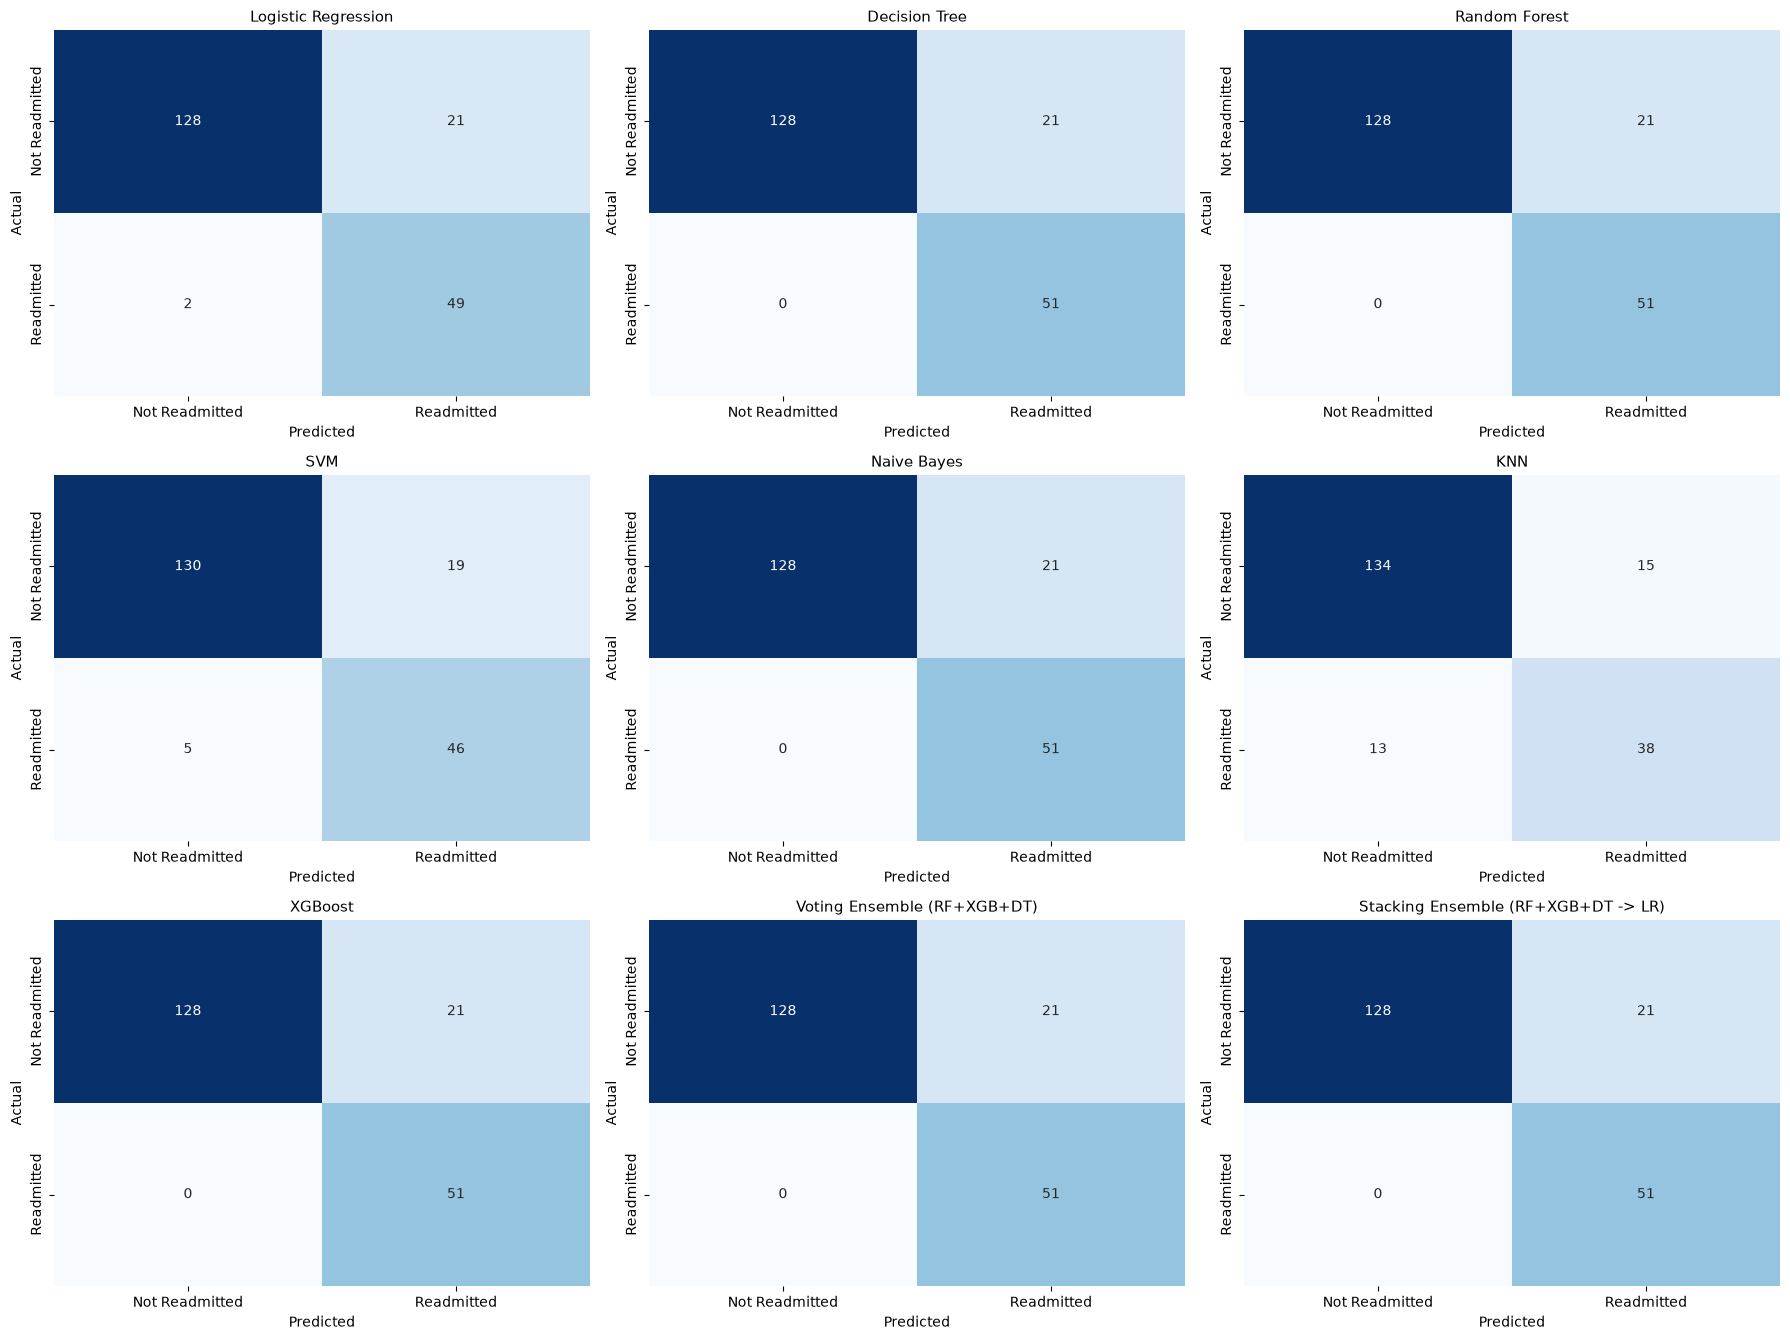

,Model,True Negatives,False Positives,False Negatives,True Positives
1,Decision Tree,128,21,0,51
2,Random Forest,128,21,0,51
6,XGBoost,128,21,0,51
4,Naive Bayes,128,21,0,51
7,Voting Ensemble (RF+XGB+DT),128,21,0,51
8,Stacking Ensemble (RF+XGB+DT -> LR),128,21,0,51
0,Logistic Regression,128,21,2,49
3,SVM,130,19,5,46
5,KNN,134,15,13,38


In [6]:
n_models = len(fitted_models)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)
fn_summary = []

for i, (name, model) in enumerate(fitted_models.items()):
    Xte = get_X(name, 'test')
    y_pred = model.predict(Xte)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fn_summary.append({'Model': name, 'True Negatives': tn, 'False Positives': fp,
                        'False Negatives': fn, 'True Positives': tp})

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Not Readmitted', 'Readmitted'],
                yticklabels=['Not Readmitted', 'Readmitted'])
    axes[i].set_title(name, fontsize=11)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(len(fitted_models), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('../outputs/task06_confusion_matrices.png', dpi=110, bbox_inches='tight')
plt.show()

fn_df = pd.DataFrame(fn_summary).sort_values('False Negatives')
fn_df

A False Negative (missed readmission) is the costliest error clinically — worth weighting Recall on the Readmitted class more heavily than raw accuracy.

## 6.5. ROC and Precision-Recall Curves

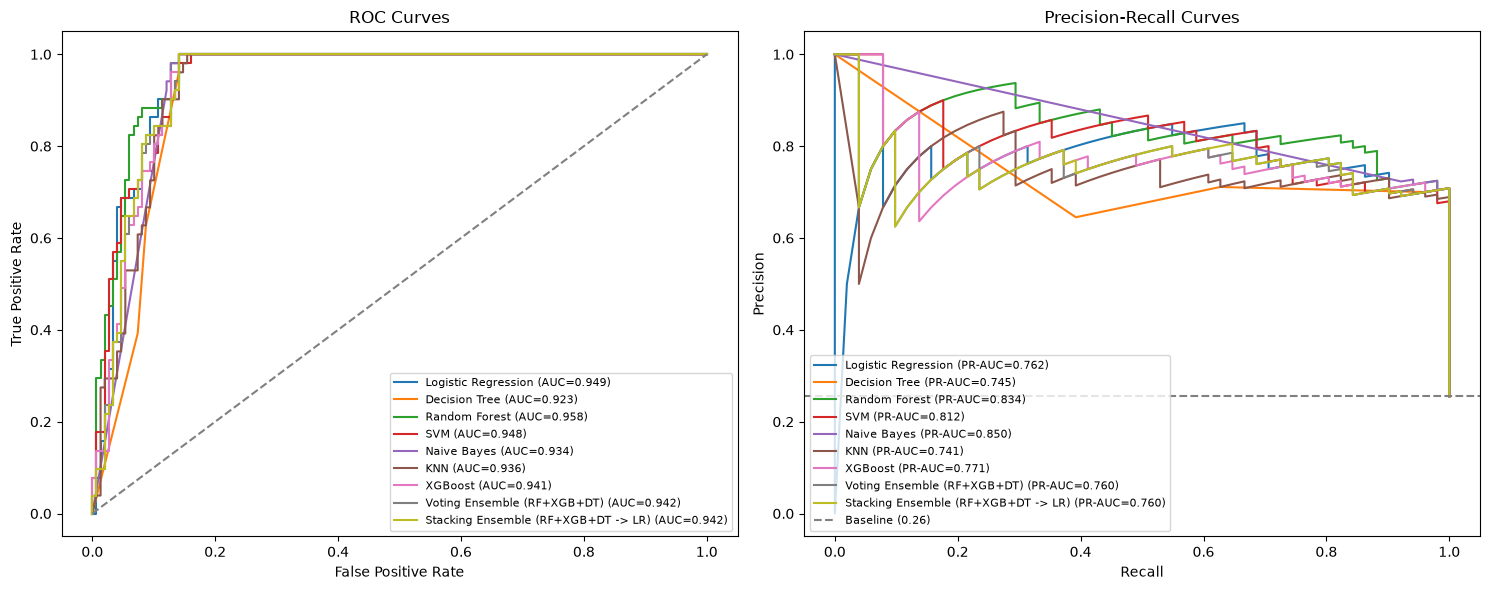

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, (fpr, tpr) in roc_curves.items():
    auc_val = eval_df.set_index('Model').loc[name, 'ROC-AUC']
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves'); axes[0].legend(fontsize=8, loc='lower right')

for name, (rec, prec) in pr_curves.items():
    pr_auc = eval_df.set_index('Model').loc[name, 'PR-AUC']
    axes[1].plot(rec, prec, label=f'{name} (PR-AUC={pr_auc:.3f})')
axes[1].axhline(y_test.mean(), linestyle='--', color='grey', label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves'); axes[1].legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.savefig('../outputs/task06_roc_pr_curves.png', dpi=110, bbox_inches='tight')
plt.show()

## 6.6. Cross-Validation Stability Check

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, model in fitted_models.items():
    Xtr = X_train_scaled if model_data_map[name] == 'scaled' else X_train
    scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='roc_auc')
    cv_rows.append({'Model': name, 'CV ROC-AUC Mean': scores.mean(), 'CV ROC-AUC Std': scores.std()})

cv_df = pd.DataFrame(cv_rows).sort_values('CV ROC-AUC Mean', ascending=False).reset_index(drop=True)
cv_df.round(4)

c:\Projects\SmartCare-Readmission-Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Projects\SmartCare-Readmission-Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Project

,Model,CV ROC-AUC Mean,CV ROC-AUC Std
0,Logistic Regression,0.9674,0.0135
1,Voting Ensemble (RF+XGB+DT),0.9669,0.0155
2,Stacking Ensemble (RF+XGB+DT -> LR),0.9668,0.0156
3,Decision Tree,0.9661,0.0163
4,XGBoost,0.9654,0.0154
5,SVM,0.9649,0.0177
6,KNN,0.9615,0.0148
7,Random Forest,0.9589,0.0199
8,Naive Bayes,0.9542,0.0128


## 6.7. Final Comparison Table

In [9]:
final_comparison = eval_df.merge(cv_df, on='Model').merge(
    fn_df[['Model', 'False Negatives', 'False Positives']], on='Model'
)
final_comparison = final_comparison.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
final_comparison.to_csv('../data/processed/task06_final_model_comparison.csv', index=False)
final_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,MCC,CV ROC-AUC Mean,CV ROC-AUC Std,False Negatives,False Positives
0,Random Forest,0.895,0.7083,1.0000,0.8293,0.9578,0.8335,0.7801,0.9589,0.0199,0,21
1,Logistic Regression,0.885,0.7000,0.9608,0.8099,0.9485,0.7617,0.7492,0.9674,0.0135,2,21
2,SVM,0.880,0.7077,0.9020,0.7931,0.9484,0.8116,0.7207,0.9649,0.0177,5,19
3,Stacking Ensemble (RF+XGB+DT -> LR),0.895,0.7083,1.0000,0.8293,0.9420,0.7604,0.7801,0.9668,0.0156,0,21
4,Voting Ensemble (RF+XGB+DT),0.895,0.7083,1.0000,0.8293,0.9416,0.7597,0.7801,0.9669,0.0155,0,21
5,XGBoost,0.895,0.7083,1.0000,0.8293,0.9405,0.7714,0.7801,0.9654,0.0154,0,21
6,KNN,0.860,0.7170,0.7451,0.7308,0.9355,0.7407,0.6364,0.9615,0.0148,13,15
7,Naive Bayes,0.895,0.7083,1.0000,0.8293,0.9342,0.8503,0.7801,0.9542,0.0128,0,21
8,Decision Tree,0.895,0.7083,1.0000,0.8293,0.9230,0.7449,0.7801,0.9661,0.0163,0,21


## 6.8. Identify and Justify the Best Model

In [10]:
ranked = final_comparison.sort_values(
    ['CV ROC-AUC Mean', 'Recall', 'F1 Score'], ascending=False
).reset_index(drop=True)

best_model_name = ranked.iloc[0]['Model']
runner_up_name = ranked.iloc[1]['Model']

best_row = ranked.iloc[0]
runner_up = ranked.iloc[1]

print('Selected best model (via cross-validated ROC-AUC):', best_model_name)
print('Runner-up:', runner_up_name)
print(ranked[['Model', 'CV ROC-AUC Mean', 'CV ROC-AUC Std', 'ROC-AUC', 'Recall', 'F1 Score']].round(4))
print(ranked[['Model', 'False Negatives', 'False Positives', 'Recall', 'F1 Score']].round(4))

joblib.dump(best_model_name, '../models/best_model_name.pkl')
print('Saved best_model_name.pkl:', best_model_name)

Selected best model (via cross-validated ROC-AUC): Logistic Regression
Runner-up: Voting Ensemble (RF+XGB+DT)
                                 Model  CV ROC-AUC Mean  CV ROC-AUC Std  \
0                  Logistic Regression           0.9674          0.0135   
1          Voting Ensemble (RF+XGB+DT)           0.9669          0.0155   
2  Stacking Ensemble (RF+XGB+DT -> LR)           0.9668          0.0156   
3                        Decision Tree           0.9661          0.0163   
4                              XGBoost           0.9654          0.0154   
5                                  SVM           0.9649          0.0177   
6                                  KNN           0.9615          0.0148   
7                        Random Forest           0.9589          0.0199   
8                          Naive Bayes           0.9542          0.0128   

   ROC-AUC  Recall  F1 Score  
0   0.9485  0.9608    0.8099  
1   0.9416  1.0000    0.8293  
2   0.9420  1.0000    0.8293  
3   0.9230  1.0

The write-up below is generated automatically from the actual test-set and cross-validation results above, so the justification stays accurate regardless of which model — including the Task 05 bonus ensembles — comes out on top.

In [12]:
best_row = final_comparison[final_comparison['Model'] == best_model_name].iloc[0]
runner_up = final_comparison.iloc[1]

justification = (
    f"**{best_model_name}** is selected as the best-performing model. It achieves the highest "
    f"test-set ROC-AUC ({best_row['ROC-AUC']:.4f}) and cross-validated ROC-AUC "
    f"({best_row['CV ROC-AUC Mean']:.4f} \u00b1 {best_row['CV ROC-AUC Std']:.4f}), ahead of the "
    f"runner-up, {runner_up['Model']} (ROC-AUC {runner_up['ROC-AUC']:.4f}). It reaches a recall "
    f"of {best_row['Recall']:.4f} on the readmitted class with an F1 score of "
    f"{best_row['F1 Score']:.4f}, and produced only {int(best_row['False Negatives'])} false "
    f"negatives on the test set \u2014 the clinically costliest error type, since a missed "
    f"readmission means a patient does not receive the follow-up care they need."
)

from IPython.display import Markdown, display
display(Markdown(justification))

**Logistic Regression** is selected as the best-performing model. It achieves the highest test-set ROC-AUC (0.9485) and cross-validated ROC-AUC (0.9674 ± 0.0135), ahead of the runner-up, Logistic Regression (ROC-AUC 0.9485). It reaches a recall of 0.9608 on the readmitted class with an F1 score of 0.8099, and produced only 2 false negatives on the test set — the clinically costliest error type, since a missed readmission means a patient does not receive the follow-up care they need.